In [10]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import pmdarima.arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings

In [11]:
data_path = 'Impute_misvalues_hungyen1.csv'  
data = pd.read_csv(data_path)
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%d/%m/%Y %H:%M')

data.set_index('DateTime', inplace=True)

In [12]:
train_size = int(len(data) * 0.9)
train = data.iloc[:train_size, :]

In [13]:
start_date = pd.to_datetime('2014-02-13')
end_date = start_date + timedelta(hours=143)
true_values = data.loc[start_date:end_date, 'Waterlevel']

In [14]:
warnings.filterwarnings(category=UserWarning, action='ignore')
arima_model = pmdarima.arima.auto_arima(train['Waterlevel'], seasonal=False, 
                                        error_action='ignore', trace=True,
                                        suppress_warnings=True, maxiter=20, stepwise=True,
                                        n_jobs=2)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=259962.391, Time=28.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=374517.930, Time=0.81 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=280220.616, Time=2.68 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=321281.216, Time=5.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=374515.941, Time=0.42 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=267993.345, Time=9.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=261235.850, Time=18.85 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=261309.472, Time=21.54 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=259530.307, Time=28.20 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=267187.894, Time=11.79 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=259459.481, Time=25.23 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=259223.686, Time=31.33 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=31.56 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=259322.910, Time=41.72 sec
 AR

In [18]:
warnings.filterwarnings('ignore')
model_arima = ARIMA(train['Waterlevel'], order=arima_model.order)
model_arima_fit = model_arima.fit()
predictions_arima = model_arima_fit.predict(start=start_date, end=end_date, dynamic=True)

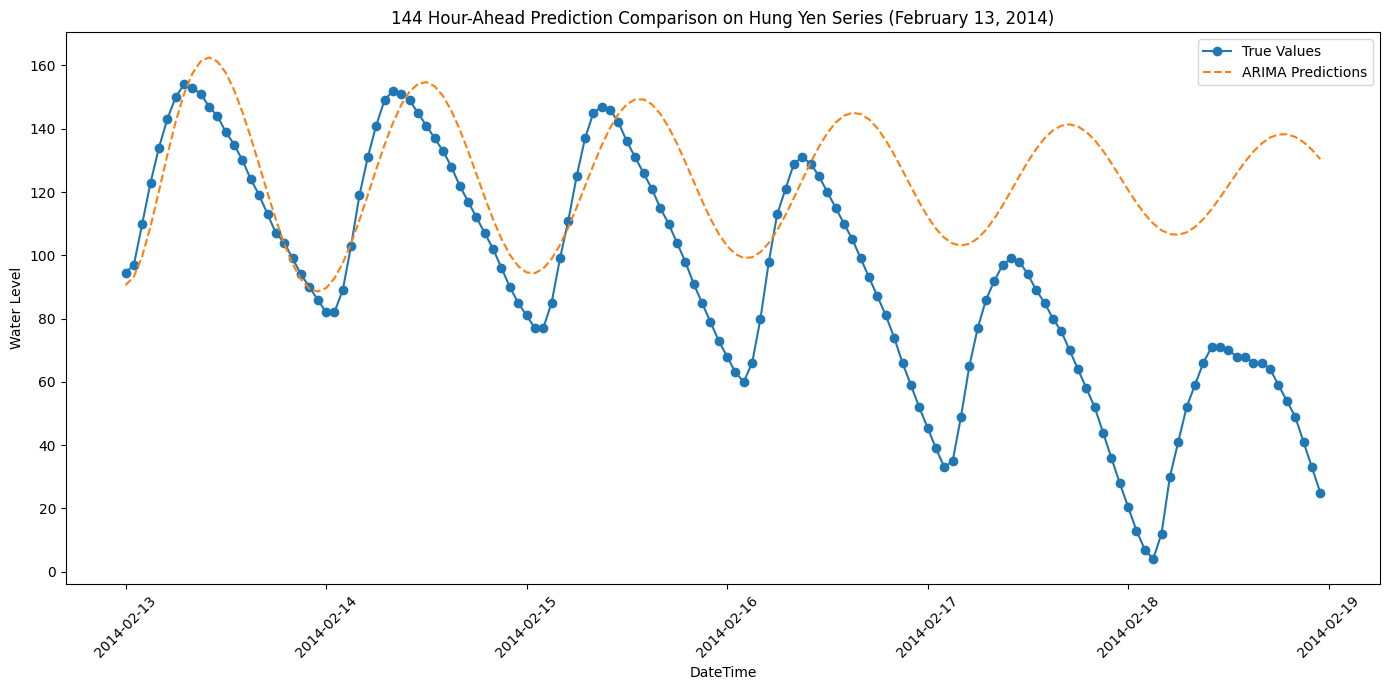

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(true_values.index, true_values, label='True Values', marker='o')
plt.plot(true_values.index, predictions_arima, label='ARIMA Predictions', linestyle='--')
plt.legend()
plt.title('144 Hour-Ahead Prediction Comparison on Hung Yen Series (February 13, 2014)')
plt.xlabel('DateTime')
plt.ylabel('Water Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# Calculate MAE
mae = mean_absolute_error(true_values, predictions_arima)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(true_values, predictions_arima))

# Calculate FSD
fsd = np.std(predictions_arima - true_values) / np.std(true_values)

# Calculate Pearson Correlation Coefficient (R)
r, _ = pearsonr(true_values, predictions_arima)

# Calculate NSE
nse_numerator = np.sum((predictions_arima - true_values) ** 2)
nse_denominator = np.sum((true_values - np.mean(true_values)) ** 2)
nse = 1 - (nse_numerator / nse_denominator)

# Display the metrics
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"FSD: {fsd}")
print(f"R: {r}")
print(f"NSE: {nse}")

MAE: 34.07287848088351
RMSE: 45.2416486708829
FSD: 0.8999905471211137
R: 0.4416701846061201
NSE: -0.5206846610805136
